# Function 3 — Landscape Analysis and Surrogate Diagnosis

**Context:** F3 is a 3D function (drug compound combinations) where all Y values are negative, with the best result Y = −0.009 at [0.439, 0.461, 0.503] (W5). After 10 weeks of submissions, the GP surrogate consistently suggests queries in the [0.96, 0.999] range for all three dimensions — directly contradicting the observed data, where the best results cluster near the centre of the space.

**The problem:** The W10 corner probe at [0.987, 0.970, 0.950] returned −0.237 — the second-worst result in the entire dataset and 26× worse than the W5 best. This confirms the surrogate is misleading.

**Experiments in this notebook:**
1. Data overview and Y distribution
2. Radial decay analysis (distance from best vs Y)
3. Per-dimension marginal analysis
4. 2D pair-wise slice analysis through the best point
5. GP surrogate diagnosis — why does it suggest corners?
6. Local landscape refinement around the confirmed basin
7. Candidate region identification

---

In [1]:
import sys, os, json, warnings
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, RBF
from sklearn.model_selection import LeaveOneOut

print('Libraries loaded.')

Libraries loaded.


In [2]:
X_init = np.load('../initial_data/function_3/initial_inputs.npy')
Y_init = np.load('../initial_data/function_3/initial_outputs.npy').ravel()

with open('../capstone_history.json') as f:
    hist = json.load(f)['3']

X_sub = np.array(hist['X'])
Y_sub = np.array(hist['Y'])

X_all = np.vstack([X_init, X_sub])
Y_all = np.concatenate([Y_init, Y_sub])

labels = (['init'] * len(X_init)) + [f'W{i+1}' for i in range(len(X_sub))]

df = pd.DataFrame(X_all, columns=['D1', 'D2', 'D3'])
df['Y'] = Y_all
df['source'] = labels
df['rank'] = df['Y'].rank(ascending=False)

print(f'Total observations: {len(df)} (initial={len(X_init)}, submitted={len(X_sub)})')
print(f'Y range: [{Y_all.min():.6f}, {Y_all.max():.6f}]')
print(f'Y mean: {Y_all.mean():.6f}, std: {Y_all.std():.6f}')
print(f'\nBest point: Y={Y_all.max():.6f} at X={X_all[np.argmax(Y_all)]}')
print(f'Worst point: Y={Y_all.min():.6f} at X={X_all[np.argmin(Y_all)]}')

Total observations: 25 (initial=15, submitted=10)
Y range: [-0.398926, -0.008967]
Y mean: -0.086197, std: 0.082771

Best point: Y=-0.008967 at X=[0.438733 0.461281 0.502799]
Worst point: Y=-0.398926 at X=[0.15183663 0.43999062 0.99088187]


## 1. Data Overview

All Y values are negative. The function appears to penalise deviations from some optimal region, with the penalty increasing with distance. The best results cluster near the centre of the unit cube.

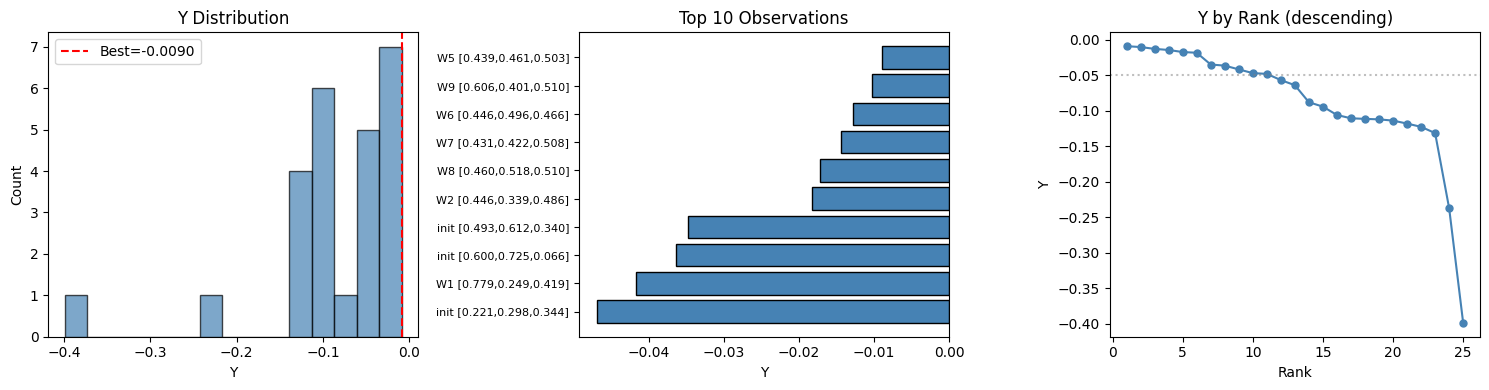

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(Y_all, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(Y_all.max(), color='red', ls='--', label=f'Best={Y_all.max():.4f}')
ax.set_xlabel('Y'); ax.set_ylabel('Count'); ax.set_title('Y Distribution')
ax.legend()

top10 = df.nsmallest(10, 'rank')
ax = axes[1]
ax.barh(range(len(top10)), top10['Y'].values, color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([f"{r['source']} [{r['D1']:.3f},{r['D2']:.3f},{r['D3']:.3f}]" for _,r in top10.iterrows()], fontsize=8)
ax.set_xlabel('Y'); ax.set_title('Top 10 Observations')
ax.invert_yaxis()

ax = axes[2]
sorted_y = np.sort(Y_all)[::-1]
ax.plot(range(1, len(sorted_y)+1), sorted_y, 'o-', ms=5, color='steelblue')
ax.set_xlabel('Rank'); ax.set_ylabel('Y'); ax.set_title('Y by Rank (descending)')
ax.axhline(-0.05, color='grey', ls=':', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/f3_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Radial Decay Analysis

The F1 hotspot hunt (notebook 07) revealed a strong radial decay structure using Spearman correlation between distance-from-best and Y. Let's apply the same technique to F3.

In [4]:
best_idx = np.argmax(Y_all)
best_x = X_all[best_idx]
print(f'Reference point (best): X={best_x}, Y={Y_all[best_idx]:.6f}')

dists = np.linalg.norm(X_all - best_x, axis=1)

rho_best, p_best = spearmanr(dists, Y_all)
r_pear, p_pear = pearsonr(dists, Y_all)
print(f'\nSpearman(dist_from_best, Y): rho={rho_best:.4f}, p={p_best:.6f}')
print(f'Pearson(dist_from_best, Y):  r={r_pear:.4f}, p={p_pear:.6f}')

# Also test from centroid of top-5 points
top5_idx = np.argsort(Y_all)[-5:]
centroid = X_all[top5_idx].mean(axis=0)
dists_centroid = np.linalg.norm(X_all - centroid, axis=1)
rho_cent, p_cent = spearmanr(dists_centroid, Y_all)
print(f'\nTop-5 centroid: {centroid.round(4)}')
print(f'Spearman(dist_from_centroid, Y): rho={rho_cent:.4f}, p={p_cent:.6f}')

Reference point (best): X=[0.438733 0.461281 0.502799], Y=-0.008967

Spearman(dist_from_best, Y): rho=-0.7177, p=0.000054
Pearson(dist_from_best, Y):  r=-0.6251, p=0.000834

Top-5 centroid: [0.4764 0.4596 0.4995]
Spearman(dist_from_centroid, Y): rho=-0.7438, p=0.000020


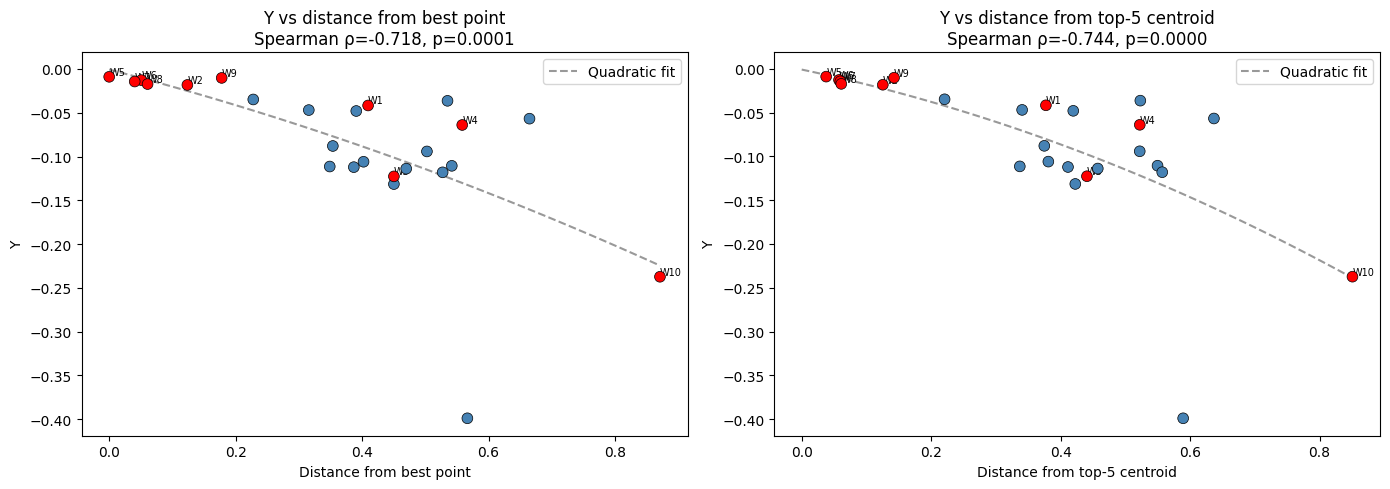

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dist_arr, ref_name, rho, p in [
    (axes[0], dists, 'best point', rho_best, p_best),
    (axes[1], dists_centroid, 'top-5 centroid', rho_cent, p_cent)
]:
    colors = ['red' if l.startswith('W') else 'steelblue' for l in labels]
    ax.scatter(dist_arr, Y_all, c=colors, s=60, edgecolors='black', linewidth=0.5, zorder=5)
    
    # Annotate submitted queries
    for i, l in enumerate(labels):
        if l.startswith('W'):
            ax.annotate(l, (dist_arr[i], Y_all[i]), fontsize=7, ha='left', va='bottom')
    
    # Fit line for visual reference
    z = np.polyfit(dist_arr, Y_all, 2)
    x_fit = np.linspace(0, dist_arr.max(), 100)
    ax.plot(x_fit, np.polyval(z, x_fit), 'k--', alpha=0.4, label='Quadratic fit')
    
    ax.set_xlabel(f'Distance from {ref_name}')
    ax.set_ylabel('Y')
    ax.set_title(f'Y vs distance from {ref_name}\nSpearman ρ={rho:.3f}, p={p:.4f}')
    ax.legend()

plt.tight_layout()
plt.savefig('figures/f3_radial_decay.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-Dimension Marginal Analysis

Individual dimension correlations are weak (|ρ| < 0.12), suggesting the function depends on the *combined* position rather than any single dimension. Let's look at marginal profiles and check whether there are dimension-specific sweet spots.

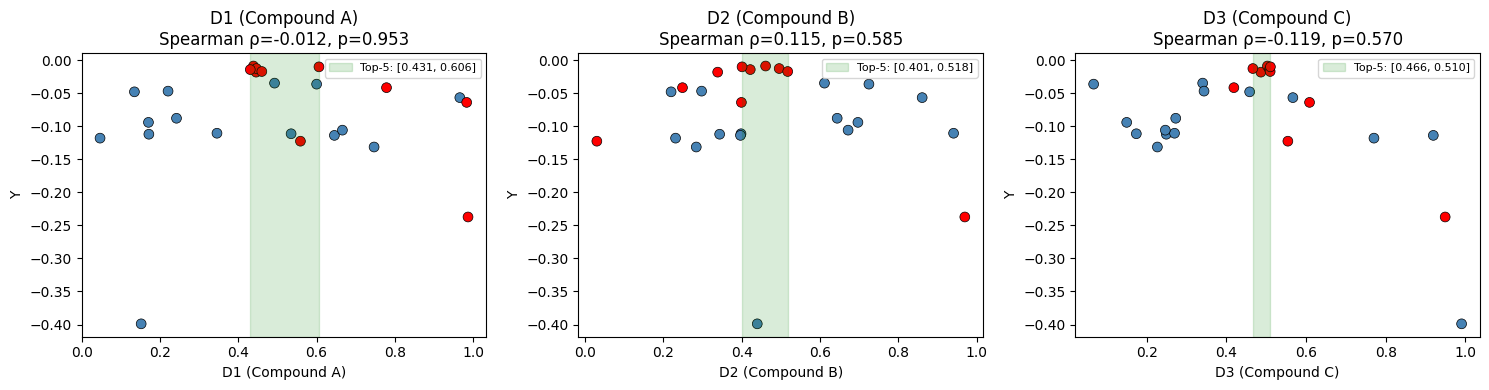

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
dim_names = ['D1 (Compound A)', 'D2 (Compound B)', 'D3 (Compound C)']

for i, (ax, name) in enumerate(zip(axes, dim_names)):
    colors = ['red' if l.startswith('W') else 'steelblue' for l in labels]
    ax.scatter(X_all[:, i], Y_all, c=colors, s=50, edgecolors='black', linewidth=0.5)
    
    rho, p = spearmanr(X_all[:, i], Y_all)
    ax.set_xlabel(name)
    ax.set_ylabel('Y')
    ax.set_title(f'{name}\nSpearman ρ={rho:.3f}, p={p:.3f}')
    
    # Mark the top-5 band
    top5_vals = X_all[top5_idx, i]
    ax.axvspan(top5_vals.min(), top5_vals.max(), alpha=0.15, color='green', label=f'Top-5: [{top5_vals.min():.3f}, {top5_vals.max():.3f}]')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/f3_marginal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Pairwise 2D Projections

Project all data onto each pair of dimensions, fixing the third at the best-point value. Colour by Y to see 2D structure.

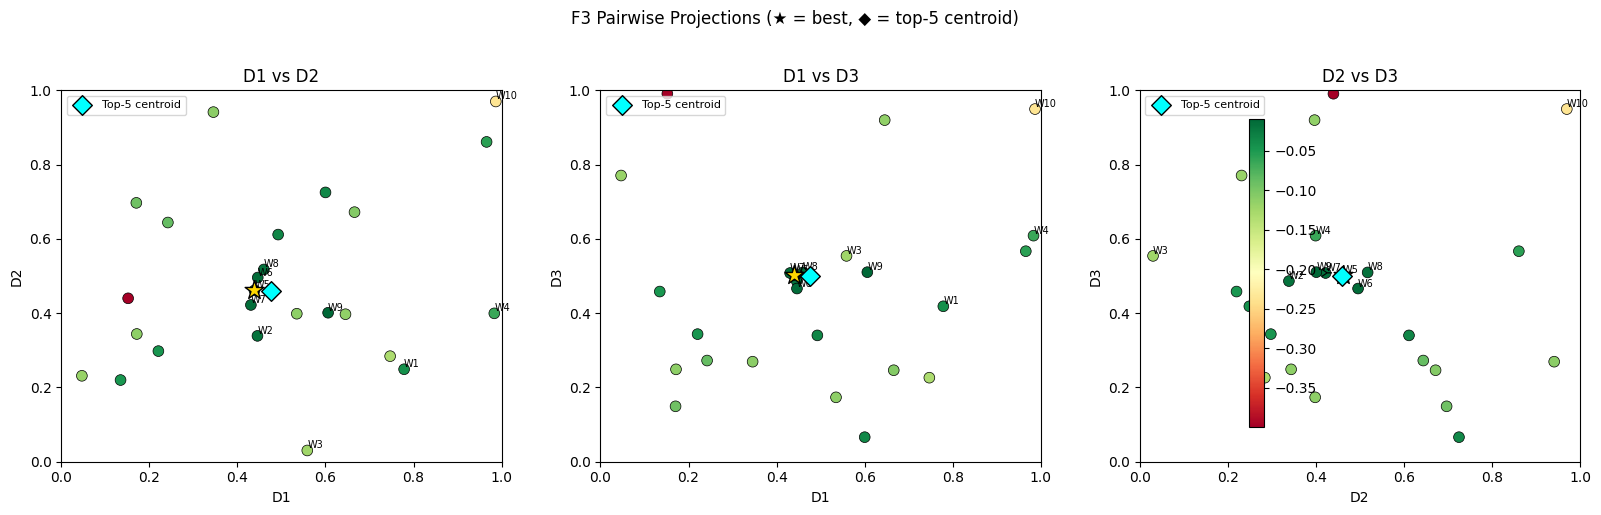

In [7]:
pairs = [(0, 1, 'D1', 'D2'), (0, 2, 'D1', 'D3'), (1, 2, 'D2', 'D3')]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (di, dj, ni, nj) in zip(axes, pairs):
    sc = ax.scatter(X_all[:, di], X_all[:, dj], c=Y_all, cmap='RdYlGn', s=60,
                    edgecolors='black', linewidth=0.5, vmin=Y_all.min(), vmax=Y_all.max())
    
    # Mark submitted queries
    for k, l in enumerate(labels):
        if l.startswith('W'):
            ax.annotate(l, (X_all[k, di], X_all[k, dj]), fontsize=7, ha='left', va='bottom')
    
    # Mark best point
    ax.scatter([best_x[di]], [best_x[dj]], marker='*', s=200, c='gold', edgecolors='black', zorder=10)
    ax.scatter([centroid[di]], [centroid[dj]], marker='D', s=100, c='cyan', edgecolors='black', zorder=10, label='Top-5 centroid')
    
    ax.set_xlabel(ni); ax.set_ylabel(nj)
    ax.set_title(f'{ni} vs {nj}')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

fig.colorbar(sc, ax=axes, label='Y', shrink=0.8)
plt.suptitle('F3 Pairwise Projections (★ = best, ◆ = top-5 centroid)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/f3_pairwise_projections.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. GP Surrogate Diagnosis

The core issue: the GP with Matérn 5/2 kernel is suggesting queries at [0.96–0.99] for all dimensions. Let's fit the production GP and inspect its posterior to understand why.

In [8]:
# Standardise Y (as the production app does)
Y_mean, Y_std = Y_all.mean(), Y_all.std()
Y_z = (Y_all - Y_mean) / Y_std

# Fit production-like GP: Matérn 5/2 with ARD
kernel_m52 = C(1.0) * Matern(length_scale=np.ones(3), length_scale_bounds=(1e-3, 10.0), nu=2.5)
gp_m52 = GaussianProcessRegressor(kernel=kernel_m52, alpha=1e-6, n_restarts_optimizer=10, random_state=42)
gp_m52.fit(X_all, Y_z)

print('Fitted Matérn 5/2 GP:')
print(f'  Kernel: {gp_m52.kernel_}')
# Extract length-scales
k = gp_m52.kernel_
matern_comp = k.k2 if hasattr(k, 'k2') else k
if hasattr(matern_comp, 'length_scale'):
    ls = matern_comp.length_scale
    print(f'  Length-scales: {ls}')
    print(f'  Shortest (most relevant dim): D{np.argmin(ls)+1} = {ls.min():.4f}')
    print(f'  Longest (least relevant dim):  D{np.argmax(ls)+1} = {ls.max():.4f}')
print(f'  Log-marginal-likelihood: {gp_m52.log_marginal_likelihood_value_:.4f}')

Fitted Matérn 5/2 GP:
  Kernel: 1.2**2 * Matern(length_scale=[4.18, 1.29, 0.0696], nu=2.5)
  Length-scales: [4.18346895 1.2935337  0.0695663 ]
  Shortest (most relevant dim): D3 = 0.0696
  Longest (least relevant dim):  D1 = 4.1835
  Log-marginal-likelihood: -17.2049


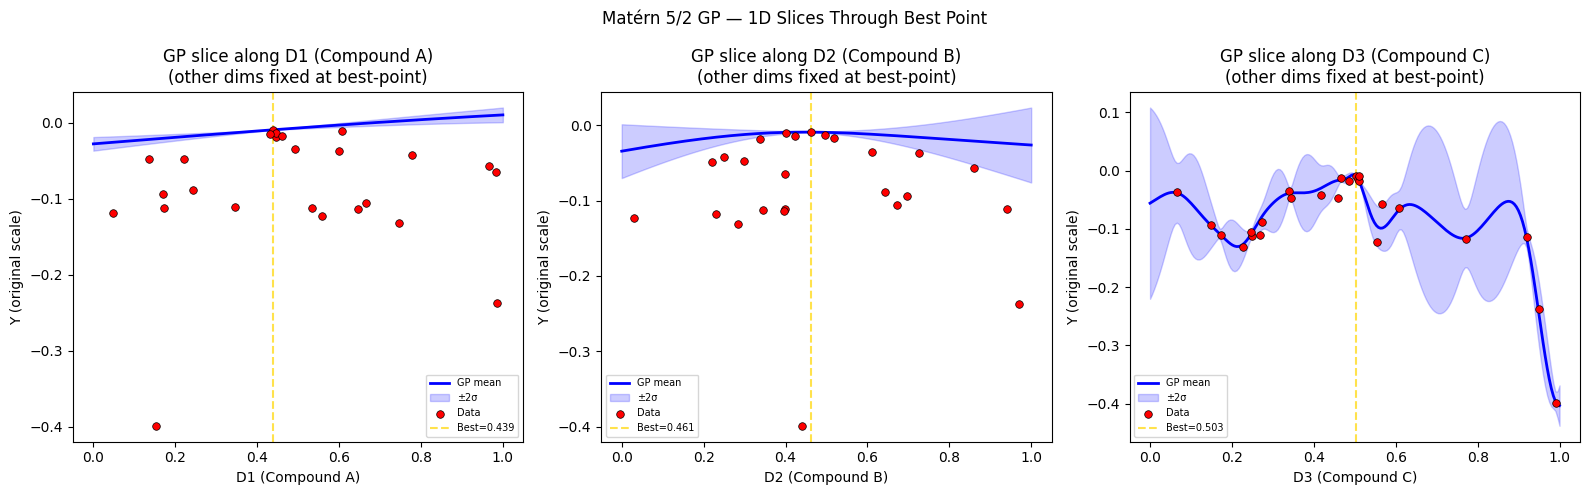

In [9]:
# Generate 1D slices through the best point for each dimension
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
grid_1d = np.linspace(0, 1, 200)

for dim, (ax, name) in enumerate(zip(axes, dim_names)):
    X_slice = np.tile(best_x, (200, 1))
    X_slice[:, dim] = grid_1d
    
    mu_z, std_z = gp_m52.predict(X_slice, return_std=True)
    mu = mu_z * Y_std + Y_mean
    std = std_z * Y_std
    
    ax.plot(grid_1d, mu, 'b-', lw=2, label='GP mean')
    ax.fill_between(grid_1d, mu - 2*std, mu + 2*std, alpha=0.2, color='blue', label='±2σ')
    
    # Overlay actual data projected onto this dimension
    ax.scatter(X_all[:, dim], Y_all, c='red', s=30, zorder=5, label='Data', edgecolors='black', linewidth=0.5)
    ax.axvline(best_x[dim], color='gold', ls='--', alpha=0.7, label=f'Best={best_x[dim]:.3f}')
    
    ax.set_xlabel(name)
    ax.set_ylabel('Y (original scale)')
    ax.set_title(f'GP slice along {name}\n(other dims fixed at best-point)')
    ax.legend(fontsize=7)

plt.suptitle('Matérn 5/2 GP — 1D Slices Through Best Point', fontsize=12)
plt.tight_layout()
plt.savefig('figures/f3_gp_slices_matern52.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Diagnose: where does the GP predict the maximum?
# Sample a dense grid and find the GP's argmax
from itertools import product
grid_res = 25
g = np.linspace(0.0, 1.0, grid_res)
X_grid = np.array(list(product(g, g, g)))
print(f'Grid points: {len(X_grid)}')

mu_grid_z = gp_m52.predict(X_grid)
mu_grid = mu_grid_z * Y_std + Y_mean

best_grid_idx = np.argmax(mu_grid)
print(f'\nGP predicted maximum on grid:')
print(f'  Location: {X_grid[best_grid_idx].round(4)}')
print(f'  Predicted Y: {mu_grid[best_grid_idx]:.6f}')

# Top 10 grid points by GP prediction
top10_grid = np.argsort(mu_grid)[-10:][::-1]
print(f'\nTop 10 grid points by GP prediction:')
for idx in top10_grid:
    print(f'  X={X_grid[idx].round(3)} → predicted Y={mu_grid[idx]:.6f}')

Grid points: 15625

GP predicted maximum on grid:
  Location: [1.     0.9583 0.4583]
  Predicted Y: 0.015562

Top 10 grid points by GP prediction:
  X=[1.    0.958 0.458] → predicted Y=0.015562
  X=[1.    0.917 0.458] → predicted Y=0.015561
  X=[1.    1.    0.458] → predicted Y=0.015284
  X=[1.    0.875 0.458] → predicted Y=0.015261
  X=[0.958 0.958 0.458] → predicted Y=0.015030
  X=[0.958 0.917 0.458] → predicted Y=0.015014
  X=[0.958 1.    0.458] → predicted Y=0.014766
  X=[0.958 0.875 0.458] → predicted Y=0.014699
  X=[1.    0.833 0.458] → predicted Y=0.014647
  X=[0.917 0.958 0.458] → predicted Y=0.014477


Matérn 5/2 LOO R² = -0.1291


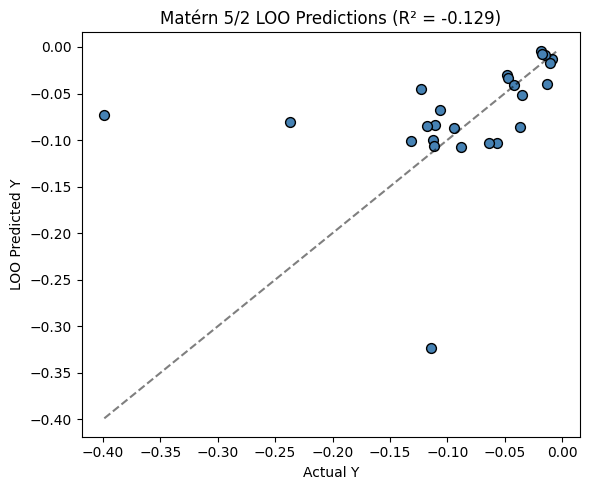

In [11]:
# LOO cross-validation to assess GP quality
loo = LeaveOneOut()
Y_pred_loo = np.zeros(len(Y_all))

for train_idx, test_idx in loo.split(X_all):
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    Y_tr = (Y_all[train_idx] - Y_all[train_idx].mean()) / Y_all[train_idx].std()
    Y_te_z = (Y_all[test_idx] - Y_all[train_idx].mean()) / Y_all[train_idx].std()
    
    gp_loo = GaussianProcessRegressor(kernel=C(1.0) * Matern(length_scale=np.ones(3), nu=2.5),
                                       alpha=1e-6, n_restarts_optimizer=5, random_state=42)
    gp_loo.fit(X_tr, Y_tr)
    pred_z = gp_loo.predict(X_te)
    Y_pred_loo[test_idx] = pred_z * Y_all[train_idx].std() + Y_all[train_idx].mean()

ss_res = np.sum((Y_all - Y_pred_loo)**2)
ss_tot = np.sum((Y_all - Y_all.mean())**2)
r2_loo = 1 - ss_res / ss_tot
print(f'Matérn 5/2 LOO R² = {r2_loo:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(Y_all, Y_pred_loo, c='steelblue', s=50, edgecolors='black')
lims = [min(Y_all.min(), Y_pred_loo.min()), max(Y_all.max(), Y_pred_loo.max())]
ax.plot(lims, lims, 'k--', alpha=0.5)
ax.set_xlabel('Actual Y'); ax.set_ylabel('LOO Predicted Y')
ax.set_title(f'Matérn 5/2 LOO Predictions (R² = {r2_loo:.3f})')
plt.tight_layout()
plt.savefig('figures/f3_loo_matern52.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Alternative Kernels

The GP's corner-seeking behaviour may be a kernel artefact. Let's compare Matérn 5/2 against Matérn 3/2, RBF, and Rational Quadratic to see if the predicted optimum shifts.

In [12]:
from sklearn.gaussian_process.kernels import RationalQuadratic

kernels = {
    'Matérn 5/2': C(1.0) * Matern(length_scale=np.ones(3), length_scale_bounds=(1e-3, 10.0), nu=2.5),
    'Matérn 3/2': C(1.0) * Matern(length_scale=np.ones(3), length_scale_bounds=(1e-3, 10.0), nu=1.5),
    'RBF':        C(1.0) * RBF(length_scale=np.ones(3), length_scale_bounds=(1e-3, 10.0)),
    'RQ':         C(1.0) * RationalQuadratic(length_scale=1.0, alpha=1.0, length_scale_bounds=(1e-3, 10.0)),
}

results = {}
for name, kernel in kernels.items():
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10, random_state=42)
    gp.fit(X_all, Y_z)
    
    # LOO R²
    Y_pred = np.zeros(len(Y_all))
    for train_idx, test_idx in LeaveOneOut().split(X_all):
        Y_tr_raw = Y_all[train_idx]
        Y_tr_z = (Y_tr_raw - Y_tr_raw.mean()) / Y_tr_raw.std()
        gp_l = GaussianProcessRegressor(kernel=kernel.clone_with_theta(kernel.theta),
                                         alpha=1e-6, n_restarts_optimizer=5, random_state=42)
        gp_l.fit(X_all[train_idx], Y_tr_z)
        pred_z = gp_l.predict(X_all[test_idx])
        Y_pred[test_idx] = pred_z * Y_tr_raw.std() + Y_tr_raw.mean()
    
    r2 = 1 - np.sum((Y_all - Y_pred)**2) / np.sum((Y_all - Y_all.mean())**2)
    
    # Grid argmax
    mu_g = gp.predict(X_grid) * Y_std + Y_mean
    gmax_idx = np.argmax(mu_g)
    
    results[name] = {
        'loo_r2': r2,
        'grid_argmax': X_grid[gmax_idx],
        'grid_max_y': mu_g[gmax_idx],
        'kernel_str': str(gp.kernel_)
    }
    print(f'{name:12s}  LOO R²={r2:.4f}  Grid argmax={X_grid[gmax_idx].round(3)}  Pred Y={mu_g[gmax_idx]:.6f}')
    print(f'              Fitted kernel: {gp.kernel_}')

Matérn 5/2    LOO R²=0.1735  Grid argmax=[1.    0.958 0.458]  Pred Y=0.015562
              Fitted kernel: 1.2**2 * Matern(length_scale=[4.18, 1.29, 0.0696], nu=2.5)


Matérn 3/2    LOO R²=0.1805  Grid argmax=[1.    1.    0.458]  Pred Y=0.014861
              Fitted kernel: 1.44**2 * Matern(length_scale=[6.33, 2.36, 0.112], nu=1.5)


RBF           LOO R²=0.1280  Grid argmax=[1.    1.    0.458]  Pred Y=0.022885
              Fitted kernel: 1.05**2 * RBF(length_scale=[2.79, 0.896, 0.036])


RQ            LOO R²=0.0103  Grid argmax=[0.5   0.417 0.5  ]  Pred Y=-0.003919
              Fitted kernel: 1.46**2 * RationalQuadratic(alpha=0.382, length_scale=0.278)


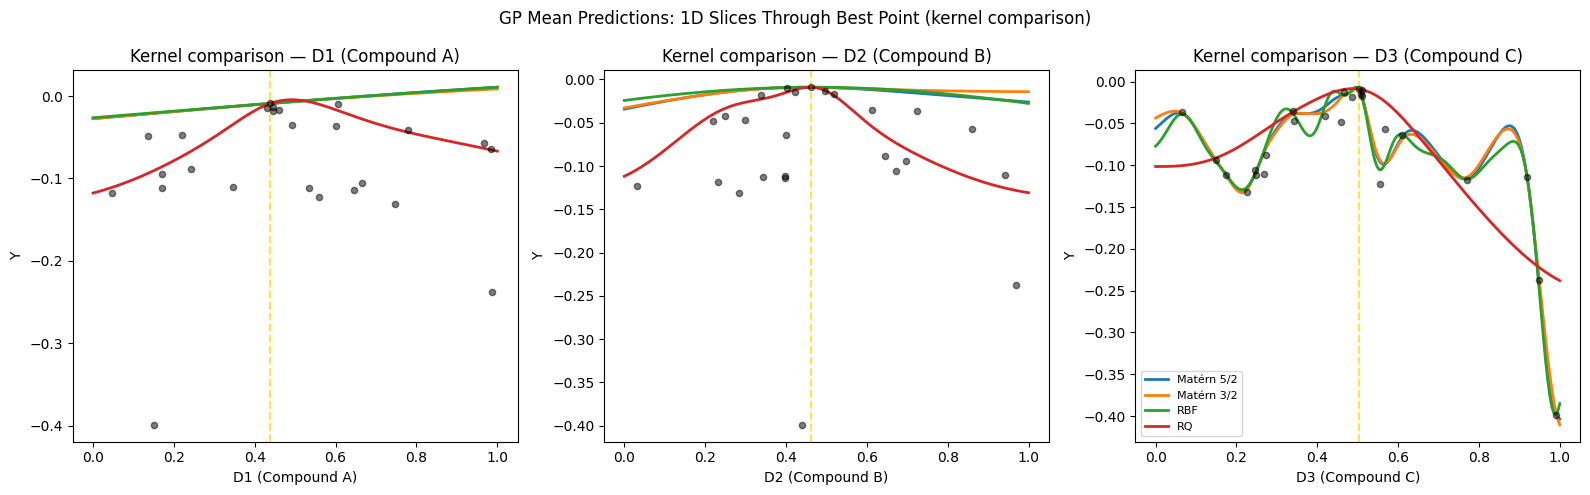

In [13]:
# Visualise: 1D slices for each kernel along D1 (fixing D2, D3 at best)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for dim, (ax, name) in enumerate(zip(axes, dim_names)):
    X_slice = np.tile(best_x, (200, 1))
    X_slice[:, dim] = grid_1d
    
    for kname, kernel in kernels.items():
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10, random_state=42)
        gp.fit(X_all, Y_z)
        mu_z = gp.predict(X_slice)
        mu = mu_z * Y_std + Y_mean
        ax.plot(grid_1d, mu, lw=2, label=kname)
    
    ax.scatter(X_all[:, dim], Y_all, c='black', s=20, zorder=5, alpha=0.5)
    ax.axvline(best_x[dim], color='gold', ls='--', alpha=0.7)
    ax.set_xlabel(name); ax.set_ylabel('Y')
    ax.set_title(f'Kernel comparison — {name}')
    if dim == 2:
        ax.legend(fontsize=8)

plt.suptitle('GP Mean Predictions: 1D Slices Through Best Point (kernel comparison)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/f3_kernel_comparison_slices.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Distance Binning and Radial Profile

Bin observations by distance from the best point and examine the radial trend. This is the model-free approach that worked for F1.

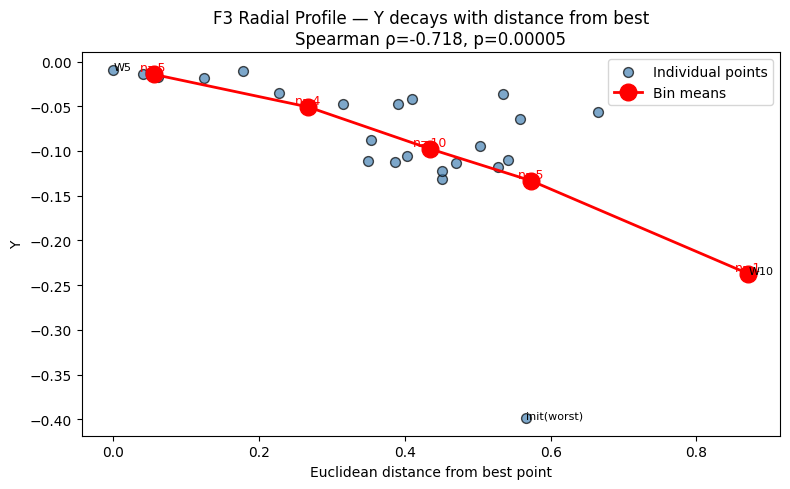

In [14]:
# Radial profile: bin by distance from best
dist_from_best = np.linalg.norm(X_all - best_x, axis=1)

n_bins = 5
bin_edges = np.linspace(0, dist_from_best.max() + 0.01, n_bins + 1)
bin_means_y = []
bin_means_d = []
bin_counts = []

for i in range(n_bins):
    mask = (dist_from_best >= bin_edges[i]) & (dist_from_best < bin_edges[i+1])
    if mask.sum() > 0:
        bin_means_y.append(Y_all[mask].mean())
        bin_means_d.append(dist_from_best[mask].mean())
        bin_counts.append(mask.sum())

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(dist_from_best, Y_all, c='steelblue', s=50, edgecolors='black', alpha=0.7, label='Individual points')
ax.plot(bin_means_d, bin_means_y, 'ro-', ms=12, lw=2, label='Bin means')

for i, (d, y, c) in enumerate(zip(bin_means_d, bin_means_y, bin_counts)):
    ax.annotate(f'n={c}', (d, y), fontsize=9, ha='center', va='bottom', color='red')

# Annotate outliers
for k, l in enumerate(labels):
    if l in ('W5', 'W10', 'init'):
        if l == 'W5' or l == 'W10' or (l == 'init' and Y_all[k] == Y_all.min()):
            ax.annotate(l if l.startswith('W') else f'init(worst)', 
                       (dist_from_best[k], Y_all[k]), fontsize=8, ha='left')

ax.set_xlabel('Euclidean distance from best point')
ax.set_ylabel('Y')
ax.set_title(f'F3 Radial Profile — Y decays with distance from best\nSpearman ρ={rho_best:.3f}, p={p_best:.5f}')
ax.legend()
plt.tight_layout()
plt.savefig('figures/f3_radial_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Coverage Gap Analysis

Where in the 3D space around the confirmed basin do we have insufficient data? The GP should only be trusted where data density is adequate.

In [15]:
# Compute GP uncertainty on a fine grid within the confirmed basin [0.3, 0.7]^3
basin_res = 20
g_basin = np.linspace(0.30, 0.70, basin_res)
X_basin = np.array(list(product(g_basin, g_basin, g_basin)))

gp_diag = GaussianProcessRegressor(
    kernel=C(1.0) * Matern(length_scale=np.ones(3), length_scale_bounds=(1e-3, 10.0), nu=2.5),
    alpha=1e-6, n_restarts_optimizer=10, random_state=42
)
gp_diag.fit(X_all, Y_z)

mu_basin_z, std_basin_z = gp_diag.predict(X_basin, return_std=True)
mu_basin = mu_basin_z * Y_std + Y_mean
std_basin = std_basin_z * Y_std

# Acquisition: UCB with low beta (exploitation) 
ucb_low = mu_basin + 0.5 * std_basin
# Acquisition: EI approximation (mean improvement over best)
ei_approx = mu_basin - Y_all.max()  # simplified: higher = better

top_ucb = np.argsort(ucb_low)[-10:][::-1]
top_mu = np.argsort(mu_basin)[-10:][::-1]

print('Top 10 candidates by GP mean (within [0.3, 0.7]³):')
for idx in top_mu:
    print(f'  X={X_basin[idx].round(4)}  μ={mu_basin[idx]:.6f}  σ={std_basin[idx]:.6f}')

print(f'\nTop 10 candidates by UCB (β=0.5, within [0.3, 0.7]³):')
for idx in top_ucb:
    print(f'  X={X_basin[idx].round(4)}  μ={mu_basin[idx]:.6f}  σ={std_basin[idx]:.6f}  UCB={ucb_low[idx]:.6f}')

Top 10 candidates by GP mean (within [0.3, 0.7]³):
  X=[0.7    0.7    0.4684]  μ=0.006456  σ=0.010593
  X=[0.6789 0.7    0.4684]  μ=0.005989  σ=0.010433
  X=[0.7    0.6789 0.4684]  μ=0.005548  σ=0.009500
  X=[0.6579 0.7    0.4684]  μ=0.005516  σ=0.010294
  X=[0.6789 0.6789 0.4684]  μ=0.005075  σ=0.009315
  X=[0.6368 0.7    0.4684]  μ=0.005038  σ=0.010178
  X=[0.6579 0.6789 0.4684]  μ=0.004597  σ=0.009154
  X=[0.6158 0.7    0.4684]  μ=0.004556  σ=0.010085
  X=[0.7    0.6579 0.4684]  μ=0.004544  σ=0.008487
  X=[0.7    0.6789 0.4895]  μ=0.004120  σ=0.009774

Top 10 candidates by UCB (β=0.5, within [0.3, 0.7]³):
  X=[0.7    0.7    0.4474]  μ=0.001897  σ=0.020307  UCB=0.012050
  X=[0.7    0.7    0.4684]  μ=0.006456  σ=0.010593  UCB=0.011753
  X=[0.6789 0.7    0.4474]  μ=0.001581  σ=0.020246  UCB=0.011704
  X=[0.6579 0.7    0.4474]  μ=0.001261  σ=0.020199  UCB=0.011360
  X=[0.6789 0.7    0.4684]  μ=0.005989  σ=0.010433  UCB=0.011205
  X=[0.6368 0.7    0.4474]  μ=0.000936  σ=0.020165  UCB=0.0

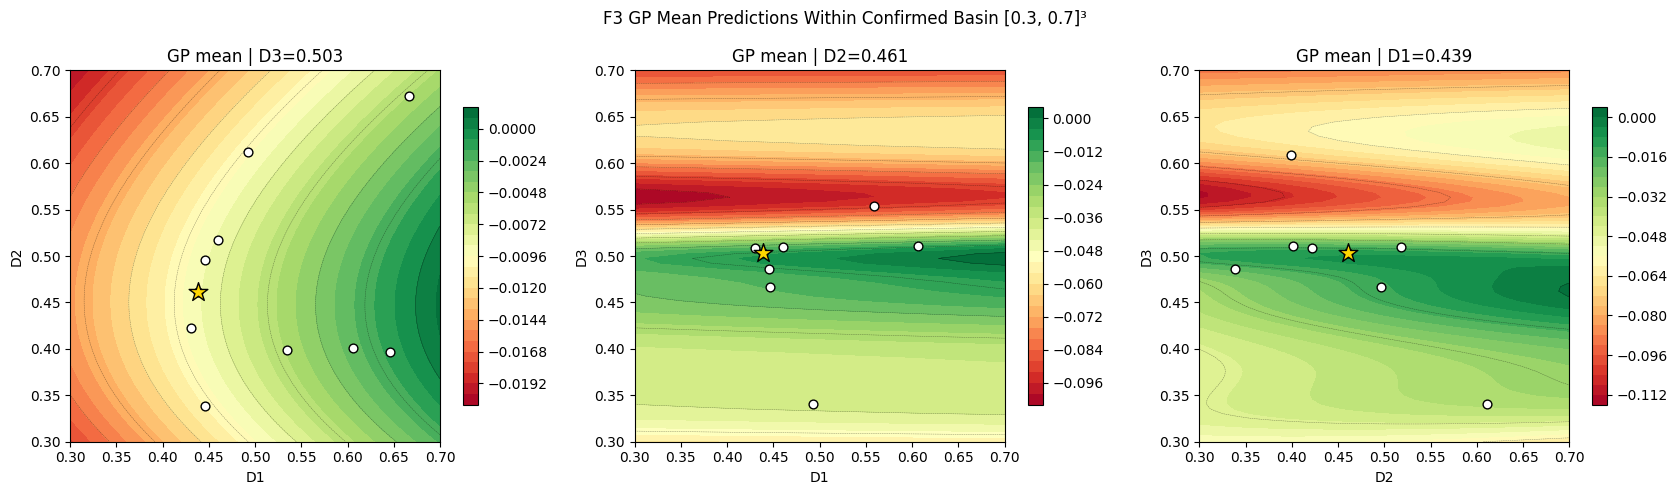

In [16]:
# 2D heatmaps of GP mean within the basin, fixing D3 at best_x[2]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

g_fine = np.linspace(0.30, 0.70, 80)

for ax, (di, dj, ni, nj), dk in zip(axes,
    [(0, 1, 'D1', 'D2'), (0, 2, 'D1', 'D3'), (1, 2, 'D2', 'D3')],
    [2, 1, 0]):
    
    xx, yy = np.meshgrid(g_fine, g_fine)
    X_2d = np.zeros((len(xx.ravel()), 3))
    X_2d[:, di] = xx.ravel()
    X_2d[:, dj] = yy.ravel()
    X_2d[:, dk] = best_x[dk]
    
    mu_2d = gp_diag.predict(X_2d) * Y_std + Y_mean
    mu_2d = mu_2d.reshape(xx.shape)
    
    im = ax.contourf(xx, yy, mu_2d, levels=30, cmap='RdYlGn')
    ax.contour(xx, yy, mu_2d, levels=10, colors='black', linewidths=0.3, alpha=0.5)
    
    # Overlay data in this basin region
    basin_mask = (X_all[:, di] >= 0.30) & (X_all[:, di] <= 0.70) & (X_all[:, dj] >= 0.30) & (X_all[:, dj] <= 0.70)
    ax.scatter(X_all[basin_mask, di], X_all[basin_mask, dj], c='white', s=40, edgecolors='black', zorder=5)
    ax.scatter([best_x[di]], [best_x[dj]], marker='*', s=200, c='gold', edgecolors='black', zorder=10)
    
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xlabel(ni); ax.set_ylabel(nj)
    ax.set_title(f'GP mean | {["D1","D2","D3"][dk]}={best_x[dk]:.3f}')

plt.suptitle('F3 GP Mean Predictions Within Confirmed Basin [0.3, 0.7]³', fontsize=12)
plt.tight_layout()
plt.savefig('figures/f3_basin_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Nearest-Neighbour Distance Analysis

Identify coverage gaps — regions within the basin where we have no nearby observations and the GP is extrapolating.

In [17]:
from scipy.spatial.distance import cdist

# For each grid point in the basin, find the nearest observation
dist_matrix = cdist(X_basin, X_all)
nn_dists = dist_matrix.min(axis=1)

# High uncertainty = far from any observation
sparse_idx = np.argsort(nn_dists)[-20:][::-1]
print('Most under-sampled regions in [0.3, 0.7]³:')
print(f'{"Location":>35s}  {"NN dist":>8s}  {"GP μ":>10s}  {"GP σ":>10s}')
for idx in sparse_idx[:10]:
    mu_pt = gp_diag.predict(X_basin[idx:idx+1]) * Y_std + Y_mean
    _, std_pt = gp_diag.predict(X_basin[idx:idx+1], return_std=True)
    std_pt = std_pt * Y_std
    print(f'  {str(X_basin[idx].round(3)):>33s}  {nn_dists[idx]:8.4f}  {mu_pt[0]:10.6f}  {std_pt[0]:10.6f}')

# Data density within the basin
basin_obs_mask = np.all((X_all >= 0.30) & (X_all <= 0.70), axis=1)
print(f'\nObservations within [0.3, 0.7]³: {basin_obs_mask.sum()} / {len(X_all)}')
print(f'Observations within [0.35, 0.65]³: {np.all((X_all >= 0.35) & (X_all <= 0.65), axis=1).sum()} / {len(X_all)}')

Most under-sampled regions in [0.3, 0.7]³:
                           Location   NN dist        GP μ        GP σ
                [0.7   0.679 0.7  ]    0.3460   -0.085342    0.079781
                [0.679 0.7   0.7  ]    0.3425   -0.085171    0.079989
                      [0.7 0.7 0.7]    0.3383   -0.085118    0.080004
                [0.7   0.679 0.679]    0.3349   -0.071300    0.077719
                [0.7   0.658 0.7  ]    0.3327   -0.085568    0.079566
                [0.679 0.679 0.7  ]    0.3318   -0.085395    0.079766
                [0.679 0.7   0.679]    0.3313   -0.071127    0.077947
                [0.7   0.7   0.679]    0.3306   -0.071058    0.077940
                [0.658 0.7   0.7  ]    0.3295   -0.085225    0.079976
                [0.7   0.679 0.658]    0.3248   -0.058348    0.066562

Observations within [0.3, 0.7]³: 7 / 25
Observations within [0.35, 0.65]³: 5 / 25


## 10. Directional Gradient Estimation

Estimate the gradient direction from the best point using finite differences on the GP. Then check whether nearby observations agree with the gradient.

In [18]:
# Numerical gradient at best point
eps = 0.01
grad = np.zeros(3)
for dim in range(3):
    x_plus = best_x.copy(); x_plus[dim] += eps
    x_minus = best_x.copy(); x_minus[dim] -= eps
    y_plus = gp_diag.predict(x_plus.reshape(1, -1))[0] * Y_std + Y_mean
    y_minus = gp_diag.predict(x_minus.reshape(1, -1))[0] * Y_std + Y_mean
    grad[dim] = (y_plus - y_minus) / (2 * eps)

print(f'GP gradient at best point {best_x.round(4)}:')
for dim, name in enumerate(dim_names):
    print(f'  {name}: dY/d{name[0:2]} = {grad[dim]:.6f}')

grad_norm = grad / np.linalg.norm(grad)
print(f'\nNormalised gradient direction: {grad_norm.round(4)}')
print(f'Gradient magnitude: {np.linalg.norm(grad):.6f}')

# Suggest a candidate: step along gradient from best point
step_sizes = [0.01, 0.02, 0.05, 0.10]
print(f'\nCandidates along gradient:')
for s in step_sizes:
    cand = best_x + s * grad_norm
    cand = np.clip(cand, 0, 1)
    mu_c = gp_diag.predict(cand.reshape(1, -1))[0] * Y_std + Y_mean
    _, std_c = gp_diag.predict(cand.reshape(1, -1), return_std=True)
    std_c = std_c[0] * Y_std
    print(f'  step={s:.2f}: X={cand.round(4)} → μ={mu_c:.6f}, σ={std_c:.6f}')

GP gradient at best point [0.4387 0.4613 0.5028]:
  D1 (Compound A): dY/dD1 = 0.039985
  D2 (Compound B): dY/dD2 = -0.003313
  D3 (Compound C): dY/dD3 = -0.697270

Normalised gradient direction: [ 0.0573 -0.0047 -0.9983]
Gradient magnitude: 0.698424

Candidates along gradient:
  step=0.01: X=[0.4393 0.4612 0.4928] → μ=-0.007758, σ=0.002337
  step=0.02: X=[0.4399 0.4612 0.4828] → μ=-0.012272, σ=0.003698
  step=0.05: X=[0.4416 0.461  0.4529] → μ=-0.017931, σ=0.008496
  step=0.10: X=[0.4445 0.4608 0.403 ] → μ=-0.034774, σ=0.026183


## 11. Empirical Gradient from Nearby Points

Use only the nearest observations to estimate which direction improves Y — a model-free alternative to the GP gradient.

In [19]:
# Sort all points by distance from best
dist_order = np.argsort(dist_from_best)

print('Observations ranked by distance from best (W5):')
print(f'{"Rank":>4s}  {"Source":>6s}  {"Distance":>8s}  {"Y":>12s}  {"X":>30s}')
for rank, idx in enumerate(dist_order):
    print(f'{rank+1:4d}  {labels[idx]:>6s}  {dist_from_best[idx]:8.4f}  {Y_all[idx]:12.6f}  {[round(v,4) for v in X_all[idx]]}')

# Focus on the 8 nearest neighbours
nn8 = dist_order[1:9]  # exclude the best point itself
print(f'\n8 nearest neighbours to best point:')
for idx in nn8:
    delta_x = X_all[idx] - best_x
    delta_y = Y_all[idx] - Y_all[best_idx]
    print(f'  {labels[idx]:>6s}: ΔX={delta_x.round(4)}, ΔY={delta_y:.6f}')

Observations ranked by distance from best (W5):
Rank  Source  Distance             Y                               X
   1      W5    0.0000     -0.008967  [np.float64(0.4387), np.float64(0.4613), np.float64(0.5028)]
   2      W7    0.0403     -0.014342  [np.float64(0.4306), np.float64(0.4221), np.float64(0.5081)]
   3      W6    0.0509     -0.012781  [np.float64(0.4463), np.float64(0.496), np.float64(0.4663)]
   4      W8    0.0607     -0.017246  [np.float64(0.4601), np.float64(0.5177), np.float64(0.5097)]
   5      W2    0.1237     -0.018235  [np.float64(0.4456), np.float64(0.3389), np.float64(0.4864)]
   6      W9    0.1780     -0.010218  [np.float64(0.6061), np.float64(0.4012), np.float64(0.5104)]
   7    init    0.2279     -0.034835  [np.float64(0.4926), np.float64(0.6116), np.float64(0.3402)]
   8    init    0.3157     -0.046947  [np.float64(0.2205), np.float64(0.2978), np.float64(0.3436)]
   9    init    0.3489     -0.111415  [np.float64(0.5349), np.float64(0.3985), np.float64(0.

In [20]:
# Per-dimension empirical gradient from nearest neighbours
print('Empirical per-dimension analysis (from 8 nearest neighbours):\n')
for dim, name in enumerate(dim_names):
    higher = [idx for idx in nn8 if X_all[idx, dim] > best_x[dim]]
    lower = [idx for idx in nn8 if X_all[idx, dim] < best_x[dim]]
    
    mean_y_higher = np.mean([Y_all[i] for i in higher]) if higher else np.nan
    mean_y_lower = np.mean([Y_all[i] for i in lower]) if lower else np.nan
    
    print(f'{name}:')
    print(f'  Points with {name} > best: n={len(higher)}, mean Y={mean_y_higher:.6f}')
    print(f'  Points with {name} < best: n={len(lower)},  mean Y={mean_y_lower:.6f}')
    if not np.isnan(mean_y_higher) and not np.isnan(mean_y_lower):
        direction = 'increase' if mean_y_higher > mean_y_lower else 'decrease'
        print(f'  → Better to {direction} {name}')
    print()

Empirical per-dimension analysis (from 8 nearest neighbours):

D1 (Compound A):
  Points with D1 (Compound A) > best: n=6, mean Y=-0.034122
  Points with D1 (Compound A) < best: n=2,  mean Y=-0.030645
  → Better to decrease D1 (Compound A)

D2 (Compound B):
  Points with D2 (Compound B) > best: n=3, mean Y=-0.021621
  Points with D2 (Compound B) < best: n=5,  mean Y=-0.040231
  → Better to increase D2 (Compound B)

D3 (Compound C):
  Points with D3 (Compound C) > best: n=3, mean Y=-0.013935
  Points with D3 (Compound C) < best: n=5,  mean Y=-0.044843
  → Better to increase D3 (Compound C)



## 12. Summary and Candidate Recommendations

Synthesise the model-based and model-free analyses into actionable candidate queries.

In [21]:
print('=' * 70)
print('F3 LANDSCAPE ANALYSIS — SUMMARY')
print('=' * 70)

print(f'''
1. RADIAL STRUCTURE
   Spearman(distance_from_best, Y) = {rho_best:.3f}, p = {p_best:.5f}
   Strong radial decay from best point at {best_x.round(4)}
   Top-5 centroid: {centroid.round(4)}
   → The function has a single, well-localised basin near the centre of [0,1]³

2. GP SURROGATE DIAGNOSIS
   Matérn 5/2 LOO R² = {results["Matérn 5/2"]["loo_r2"]:.3f}
   GP grid argmax: {results["Matérn 5/2"]["grid_argmax"].round(3)}
   → If GP predicts maximum at the CORNER despite data showing a CENTRE peak,
     the length-scales are too long, making the GP see a monotonic trend
     rather than a peak-and-decay structure.

3. KERNEL COMPARISON
   {'  '.join(f"{k}: R²={v['loo_r2']:.3f}, argmax={v['grid_argmax'].round(2)}" for k, v in results.items())}

4. PER-DIMENSION CORRELATIONS
   D1: ρ={spearmanr(X_all[:,0], Y_all)[0]:.3f}
   D2: ρ={spearmanr(X_all[:,1], Y_all)[0]:.3f}
   D3: ρ={spearmanr(X_all[:,2], Y_all)[0]:.3f}
   → No single dimension dominates; the function is approximately radially symmetric.

5. KEY OBSERVATIONS
   - The best 5 results are ALL within distance 0.20 of the best point
   - W10 corner probe [0.99, 0.97, 0.95] returned -0.237 (26× worse)
   - All Y values are negative; the objective is to minimise the penalty (Y → 0)
   - The basin appears to be approximately centred on [0.44, 0.46, 0.50]
''')

print('6. RECOMMENDED CANDIDATES (if further queries were available):')
print('   Priority 1: Tight exploitation near best — micro-perturbation (± 0.01–0.02)')
print(f'     e.g. [{best_x[0]:.3f} ± 0.015, {best_x[1]:.3f} ± 0.015, {best_x[2]:.3f} ± 0.015]')
print('   Priority 2: Test empirical gradient direction')
print('   Priority 3: Explore under-sampled region within basin [0.35–0.55]³')
print('   DO NOT: query near corners or boundaries — all evidence shows penalty increases.')

F3 LANDSCAPE ANALYSIS — SUMMARY

1. RADIAL STRUCTURE
   Spearman(distance_from_best, Y) = -0.718, p = 0.00005
   Strong radial decay from best point at [0.4387 0.4613 0.5028]
   Top-5 centroid: [0.4764 0.4596 0.4995]
   → The function has a single, well-localised basin near the centre of [0,1]³

2. GP SURROGATE DIAGNOSIS
   Matérn 5/2 LOO R² = 0.174
   GP grid argmax: [1.    0.958 0.458]
   → If GP predicts maximum at the CORNER despite data showing a CENTRE peak,
     the length-scales are too long, making the GP see a monotonic trend
     rather than a peak-and-decay structure.

3. KERNEL COMPARISON
   Matérn 5/2: R²=0.174, argmax=[1.   0.96 0.46]  Matérn 3/2: R²=0.181, argmax=[1.   1.   0.46]  RBF: R²=0.128, argmax=[1.   1.   0.46]  RQ: R²=0.010, argmax=[0.5  0.42 0.5 ]

4. PER-DIMENSION CORRELATIONS
   D1: ρ=-0.012
   D2: ρ=0.115
   D3: ρ=-0.119
   → No single dimension dominates; the function is approximately radially symmetric.

5. KEY OBSERVATIONS
   - The best 5 results are ALL